# Imports, configs and Paths

In [1]:
import os
import random
import time

import numpy as np
import pandas as pd
from PIL import Image

import json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import multiprocessing
multiprocessing.set_start_method("spawn", force=True)

# ---- Step 1: Choose dataset version ----
DATASET_VERSION = 2   # change to 2 to use Data2

BASE_DIR = r"C:/Users/CSIS-PostGrad/multimodal_pipeline"
DATA_DIR = os.path.join(BASE_DIR, f"Data{'' if DATASET_VERSION == 1 else '2'}")

print("Using dataset:", DATA_DIR)

TSV_FILES = {
    "train": os.path.join(DATA_DIR, "multimodal_train.tsv"),
    "validate": os.path.join(DATA_DIR, "multimodal_validate.tsv"),
    "test": os.path.join(DATA_DIR, "multimodal_test_public.tsv")
}

IMAGE_DIRS = {
    "train": os.path.join(DATA_DIR, "train_images"),
    "validate": os.path.join(DATA_DIR, "validate_images"),
    "test": os.path.join(DATA_DIR, "test_images")
}

# ---- Task config ----
LABEL_COLUMN = "6_way_label"   # change to "2_way_label" if you want binary
NUM_CLASSES = 6                # set to 2 if you change the label column above

BATCH_SIZE = 64
NUM_EPOCHS = 15
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 3  # early stopping

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using dataset: C:/Users/CSIS-PostGrad/multimodal_pipeline\Data2
Using device: cpu


# Dataset Class (Image-only FakedditDataset)

In [2]:
class FakedditImageDataset(Dataset):
    def __init__(self, tsv_path, images_dir, label_column=LABEL_COLUMN, transform=None):
        self.images_dir = images_dir
        self.label_column = label_column
        self.transform = transform

        df = pd.read_csv(tsv_path, sep="\t")
        print(f"Loaded {len(df)} rows from {tsv_path}")

        # Keep only rows with images if hasImage column exists
        if "hasImage" in df.columns:
            df = df[df["hasImage"] == True]
            print(f"After hasImage filter: {len(df)} rows")

        # Build image_path column
        df["image_path"] = df["id"].astype(str).apply(
            lambda x: os.path.join(images_dir, f"{x}.jpg")
        )

        # Filter to files that actually exist
        df = df[df["image_path"].apply(os.path.exists)]
        print(f"After image file exists filter: {len(df)} rows")

        # Keep only what we need
        self.df = df[["image_path", label_column]].reset_index(drop=True)

        # Check label range
        unique_labels = sorted(self.df[label_column].unique())
        print("Unique labels:", unique_labels)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["image_path"]
        label = int(row[self.label_column])

        # Load image
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


# Transforms & DataLoaders

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_dataset = FakedditImageDataset(
    TSV_FILES["train"], IMAGE_DIRS["train"],
    label_column=LABEL_COLUMN, transform=train_transform
)
val_dataset = FakedditImageDataset(
    TSV_FILES["validate"], IMAGE_DIRS["validate"],
    label_column=LABEL_COLUMN, transform=val_test_transform
)
test_dataset = FakedditImageDataset(
    TSV_FILES["test"], IMAGE_DIRS["test"],
    label_column=LABEL_COLUMN, transform=val_test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,      # 4 for CPU-only, 8–12 for GPU machines
    pin_memory=False,   # True only if using CUDA
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

len(train_dataset), len(val_dataset), len(test_dataset)


Loaded 564000 rows from C:/Users/CSIS-PostGrad/multimodal_pipeline\Data2\multimodal_train.tsv
After hasImage filter: 564000 rows
After image file exists filter: 374760 rows
Unique labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Loaded 59342 rows from C:/Users/CSIS-PostGrad/multimodal_pipeline\Data2\multimodal_validate.tsv
After hasImage filter: 59342 rows
After image file exists filter: 39346 rows
Unique labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Loaded 59319 rows from C:/Users/CSIS-PostGrad/multimodal_pipeline\Data2\multimodal_test_public.tsv
After hasImage filter: 59319 rows
After image file exists filter: 39625 rows
Unique labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


(374760, 39346, 39625)

# ResNet50 Model for Image Classification

In [4]:
class ImageOnlyResNet50(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, pretrained=True, freeze_backbone=False, dropout=0.5):
        super().__init__()
        self.backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None)

        # Optionally freeze backbone
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        in_features = self.backbone.fc.in_features
        # Replace final FC with a small head
        self.backbone.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

model = ImageOnlyResNet50(num_classes=NUM_CLASSES, pretrained=True, freeze_backbone=False, dropout=0.5)
model = model.to(device)
print(model.backbone.fc)


Sequential(
  (0): Linear(in_features=2048, out_features=512, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=512, out_features=6, bias=True)
)


# Training Utilities (Early Stopping + Curves)

In [5]:
class EarlyStopping:
    def __init__(self, patience=PATIENCE, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0
        self.should_stop = False
        self.best_state_dict = None

    def step(self, val_loss, model):
        if self.best_loss is None or val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        
        total_loss += loss.item() * batch_size
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += batch_size

        progress_bar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{(correct/total):.4f}"
        })

    avg_loss = total_loss / total
    avg_acc = correct / total
    return avg_loss, avg_acc


def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    progress_bar = tqdm(loader, desc="Validating", leave=False)

    with torch.no_grad():
        for images, labels in progress_bar:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            batch_size = labels.size(0)

            total_loss += loss.item() * batch_size
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += batch_size

            progress_bar.set_postfix({
                "loss": f"{loss.item():.4f}",
                "acc": f"{(correct/total):.4f}"
            })

    return total_loss / total, correct / total



def plot_learning_curves(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Curves")
    plt.legend()
    plt.grid(True)

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["val_acc"], label="Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy Curves")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


# Full Training Loop

In [6]:
pip install --upgrade torch torchvision torchaudio


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
batch = next(iter(train_loader))
print("Batch loaded!")
for b in batch:
    print(type(b), b.shape if hasattr(b, 'shape') else None)


Batch loaded!
<class 'torch.Tensor'> torch.Size([64, 3, 224, 224])
<class 'torch.Tensor'> torch.Size([64])


In [8]:
for i in range(5):
    x = train_dataset[i]
    print("Loaded sample:", i)


Loaded sample: 0
Loaded sample: 1
Loaded sample: 2
Loaded sample: 3
Loaded sample: 4


In [9]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")


False
No GPU



=== Epoch 1/15 ===


Training:   0%|          | 0/5856 [00:00<?, ?it/s]

Validating:   0%|          | 0/615 [00:00<?, ?it/s]

 Train → Loss: 0.8606, Acc: 0.6810
 Val   → Loss: 0.7620, Acc: 0.7184
 Time: 44963.69 sec

=== Epoch 2/15 ===


Training:   0%|          | 0/5856 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/615 [00:00<?, ?it/s]

 Train → Loss: 0.6816, Acc: 0.7491
 Val   → Loss: 0.7130, Acc: 0.7460
 Time: 42864.85 sec

=== Epoch 9/15 ===


Training:   0%|          | 0/5856 [00:00<?, ?it/s]

Validating:   0%|          | 0/615 [00:00<?, ?it/s]

⚠ Learning rate reduced: 0.000100 → 0.000050
 Train → Loss: 0.6698, Acc: 0.7528
 Val   → Loss: 0.7188, Acc: 0.7425
 Time: 42824.59 sec
🚨 Early stopping triggered!
💾 Best model saved to: C:/Users/CSIS-PostGrad/multimodal_pipeline\Data2\best_image_model_resnet50.pth
📊 Training history saved to: C:/Users/CSIS-PostGrad/multimodal_pipeline\Data2\image_model_training_history.json


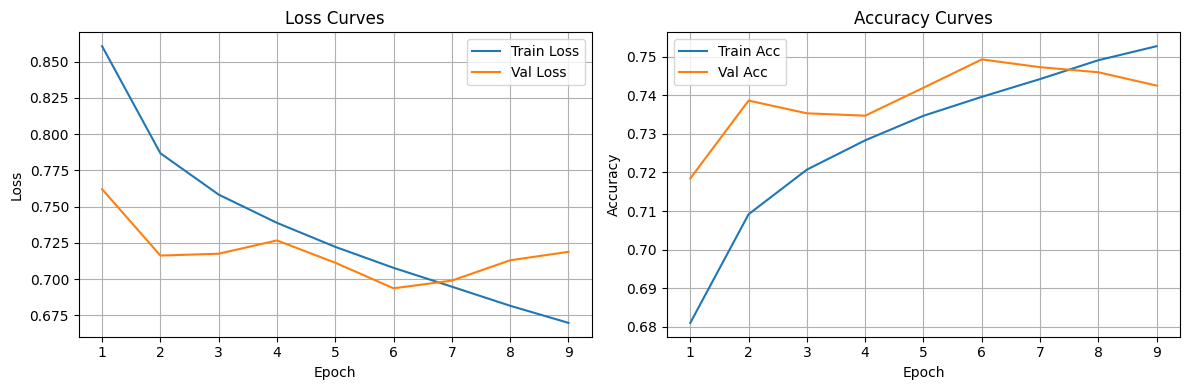

In [10]:
# ====================================
# LOSS, OPTIMIZER, SCHEDULER, STOPPER
# ====================================
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# No verbose parameter (your PyTorch version doesn’t support it)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

early_stopper = EarlyStopping(
    patience=PATIENCE,
    min_delta=0.0
)

# For storing all metrics
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "lr_changes": []
}

best_model_path = os.path.join(DATA_DIR, "best_image_model_resnet50.pth")

# ====================================
# TRAINING LOOP
# ====================================
for epoch in range(1, NUM_EPOCHS + 1):

    print(f"\n=== Epoch {epoch}/{NUM_EPOCHS} ===")
    start_time = time.time()

    # --- Training ---
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    # --- Validation ---
    val_loss, val_acc = eval_one_epoch(
        model, val_loader, criterion, device
    )

    # --- LR Scheduler ---
    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)
    new_lr = optimizer.param_groups[0]['lr']

    if new_lr != old_lr:
        print(f"Learning rate reduced: {old_lr:.6f} → {new_lr:.6f}")
        history["lr_changes"].append({
            "epoch": epoch,
            "old_lr": old_lr,
            "new_lr": new_lr
        })

    # --- Save metrics ---
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    # --- Epoch summary ---
    elapsed = time.time() - start_time
    print(f" Train → Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
    print(f" Val   → Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
    print(f" Time: {elapsed:.2f} sec")

    # --- Early stopping ---
    early_stopper.step(val_loss, model)

    if early_stopper.should_stop:
        print("Early stopping triggered!")
        break

# ====================================
# RESTORE BEST MODEL
# ====================================
if early_stopper.best_state_dict is not None:
    model.load_state_dict(early_stopper.best_state_dict)

# ====================================
# SAVE BEST MODEL
# ====================================
torch.save(model.state_dict(), best_model_path)
print("Best model saved to:", best_model_path)

# ====================================
# SAVE TRAINING HISTORY
# ====================================
history_path = os.path.join(DATA_DIR, "image_model_training_history.json")
with open(history_path, "w") as f:
    json.dump(history, f, indent=4)

print("Training history saved to:", history_path)

# ====================================
# PLOT LEARNING CURVES
# ====================================
plot_learning_curves(history)


# Evaluation on Test Set

In [11]:
model.eval()
all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

print("Classification report (test):")
print(classification_report(all_labels, all_preds, digits=4))

cm = confusion_matrix(all_labels, all_preds)
print("Confusion matrix:\n", cm)


Classification report (test):
              precision    recall  f1-score   support

           0     0.7658    0.9009    0.8278     22004
           1     0.7258    0.6138    0.6651      3291
           2     0.7247    0.5971    0.6548     10520
           3     0.4379    0.0560    0.0993      1197
           4     0.8532    0.7926    0.8218       352
           5     0.8117    0.6484    0.7209      2261

    accuracy                         0.7555     39625
   macro avg     0.7198    0.6015    0.6316     39625
weighted avg     0.7450    0.7555    0.7402     39625

Confusion matrix:
 [[19823   300  1719    16    26   120]
 [ 1017  2020   167     7     3    77]
 [ 3772   289  6282    51    13   113]
 [  681    64   354    67     4    27]
 [   37    12    20     1   279     3]
 [  557    98   127    11     2  1466]]
